# 01 · Análisis exploratorio (EDA) sobre Silver

**Objetivo:** documentar con cifras cómo son los datos limpios, para justificar las decisiones del pipeline y del modelo.

**Requisito:** haber corrido el pipeline al menos hasta Silver y Gold KPIs:
`python -m src.pipeline --etapas bronze silver gold_kpis`

Cada gráfico se guarda en `docs/evidencias/` para el README y la presentación.

In [13]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # para importar src/ desde notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

from src.config import SILVER, GOLD, META, TABLE_FORMAT, get_spark, ruta
from src.graficos import estilo, guardar, etiquetar_barras, LEGITIMA, FRAUDE, MODELO_2, REFERENCIA, TEXTO_2

estilo()
spark = get_spark("notebook")
print("Spark", spark.version)

Spark 3.5.8


In [14]:
silver = spark.read.format(TABLE_FORMAT).load(ruta(SILVER, "transacciones"))
train = silver.filter(F.col("dataset") == "train").cache()
n_train = train.count()
print(f"Filas por dataset: {dict(silver.groupBy('dataset').count().collect())}")
print(f"Columnas en Silver: {len(silver.columns)}")

Filas por dataset: {'train': 590540, 'test': 506691}
Columnas en Silver: 430


## 1. Estadística descriptiva de las variables principales

In [15]:
columnas = ["TransactionAmt", "dist1", "C1", "C13", "D1", "hora"]
columnas = [c for c in columnas if c in train.columns]
train.select(columnas).describe().toPandas().set_index("summary").astype(float).round(2)

,TransactionAmt,dist1,C1,C13,D1,hora
summary,,,,,,
count,590540.00,238269.00,590540.00,590540.00,589271.00,590540.00
mean,135.03,118.50,14.09,32.54,94.35,13.86
stddev,239.16,371.87,133.57,129.36,157.66,7.61
min,0.25,0.00,0.00,0.00,0.00,0.00
max,31937.39,10286.00,4685.00,2918.00,640.00,23.00


## 2. Desbalance de clases

El dato que define cómo se evalúa el modelo: si el fraude es una fracción pequeña, **accuracy no sirve**.

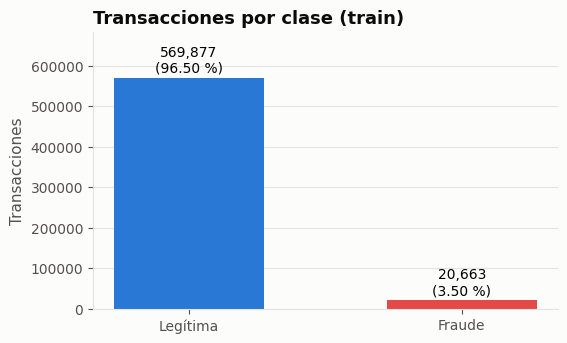

Fraude: 3.50 % -> un modelo que diga siempre 'no es fraude' tendría 96.5 % de accuracy


In [16]:
clases = train.groupBy("isFraud").count().toPandas().sort_values("isFraud")
clases["pct"] = 100 * clases["count"] / clases["count"].sum()

fig, ax = plt.subplots(figsize=(6, 3.6))
barras = ax.bar(["Legítima", "Fraude"], clases["count"], color=[LEGITIMA, FRAUDE], width=0.55)
for b, pct in zip(barras, clases["pct"]):
    ax.annotate(f"{b.get_height():,.0f}\n({pct:.2f} %)", (b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10)
ax.set_title("Transacciones por clase (train)")
ax.set_ylabel("Transacciones")
ax.set_ylim(0, clases["count"].max() * 1.2)
guardar(fig, "01_desbalance")
plt.show()

tasa_global = float(clases.loc[clases.isFraud == 1, "pct"].iloc[0])
print(f"Fraude: {tasa_global:.2f} % -> un modelo que diga siempre 'no es fraude' tendría {100 - tasa_global:.1f} % de accuracy")

## 3. Nulos

Silver ya eliminó las columnas con más de 90 % de nulos. Aquí se ve cuánto faltan las que quedaron.

Columnas con algún nulo: 405 de 430  ·  con más de 50 %: 204
Columnas eliminadas en Silver por superar el 90 %: 12 -> ['D7', 'dist2', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


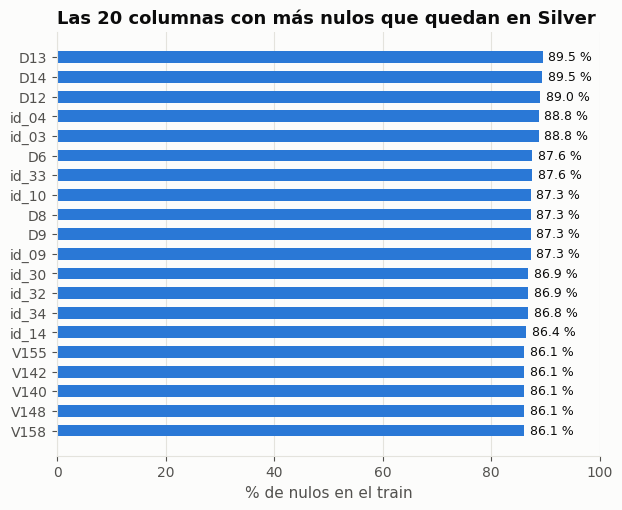

In [17]:
from src.silver_limpieza import fraccion_nulos

nulos = pd.Series(fraccion_nulos(train)).mul(100).sort_values(ascending=False)
print(f"Columnas con algún nulo: {(nulos > 0).sum()} de {len(nulos)}  ·  con más de 50 %: {(nulos > 50).sum()}")
eliminadas = json.loads((META / "silver_columnas_eliminadas.json").read_text(encoding="utf-8"))
print(f"Columnas eliminadas en Silver por superar el 90 %: {len(eliminadas)} -> {list(eliminadas)}")

top = nulos.head(20)[::-1]
fig, ax = plt.subplots(figsize=(7, 5.5))
barras = ax.barh(top.index, top.values, color=LEGITIMA, height=0.6)
etiquetar_barras(ax, barras, "{:.1f} %", horizontal=True)
ax.set_title("Las 20 columnas con más nulos que quedan en Silver")
ax.set_xlabel("% de nulos en el train")
ax.set_xlim(0, 100)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
guardar(fig, "01_nulos_top20")
plt.show()

## 4. Monto: distribución y outliers

Los montos tienen una cola larga, por eso se miran en escala logarítmica.

            count    mean     std   min   50%     99%       max
isFraud                                                        
0        569877.0  134.51  239.40  0.25  68.5  1104.0  31937.39
1         20663.0  149.24  232.21  0.29  75.0   994.0   5191.00


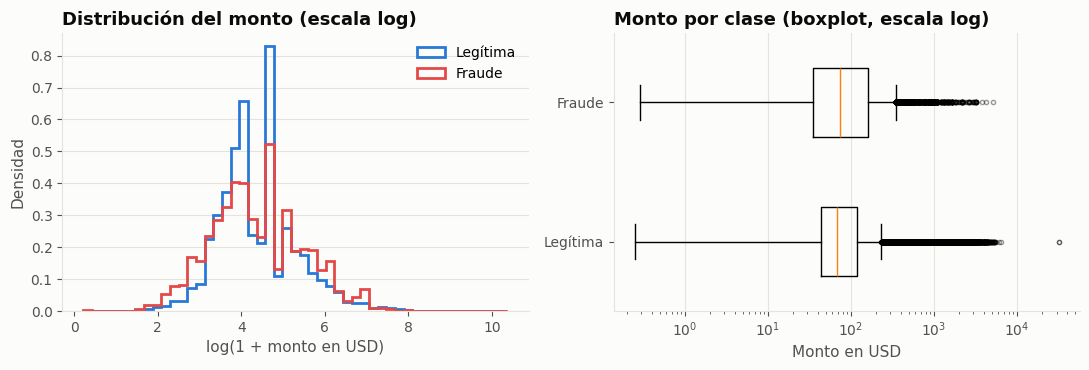

In [18]:
montos = train.select("TransactionAmt", "isFraud").toPandas()
print(montos.groupby("isFraud")["TransactionAmt"].describe(percentiles=[.5, .99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(np.log1p(montos.TransactionAmt).min(), np.log1p(montos.TransactionAmt).max(), 50)
for clase, color, nombre in [(0, LEGITIMA, "Legítima"), (1, FRAUDE, "Fraude")]:
    axes[0].hist(np.log1p(montos.loc[montos.isFraud == clase, "TransactionAmt"]), bins=bins, density=True,
                 histtype="step", linewidth=2, color=color, label=nombre)
axes[0].set_title("Distribución del monto (escala log)")
axes[0].set_xlabel("log(1 + monto en USD)"); axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].boxplot([montos.loc[montos.isFraud == c, "TransactionAmt"] for c in (0, 1)], tick_labels=["Legítima", "Fraude"],
                vert=False, widths=0.5, flierprops={"markersize": 3, "alpha": 0.4})
axes[1].set_xscale("log")
axes[1].set_title("Monto por clase (boxplot, escala log)")
axes[1].set_xlabel("Monto en USD")
axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
fig.tight_layout()
guardar(fig, "01_monto_outliers")
plt.show()

## 5. Tendencia temporal

`dia` es relativo: se cuenta desde una fecha de referencia que Vesta no publicó.
Volumen y tasa de fraude tienen escalas distintas, así que van en dos gráficos.

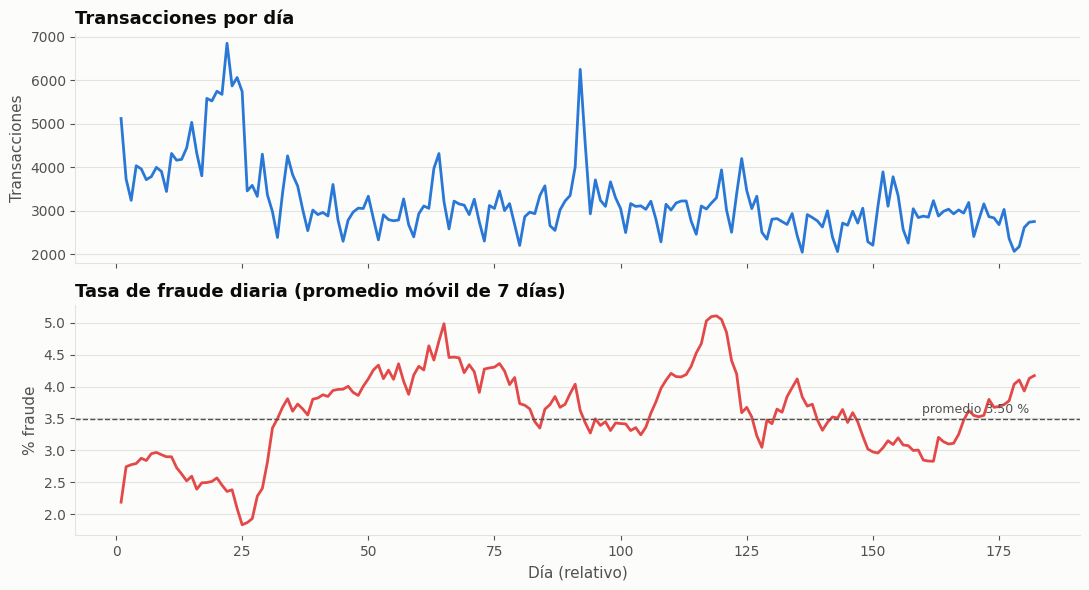

In [19]:
diarios = spark.read.format(TABLE_FORMAT).load(ruta(GOLD, "kpis_diarios")).toPandas().sort_values("dia")
diarios["tasa_7d"] = diarios["tasa_fraude_pct"].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(diarios.dia, diarios.transacciones, color=LEGITIMA)
axes[0].set_title("Transacciones por día")
axes[0].set_ylabel("Transacciones")
axes[1].plot(diarios.dia, diarios.tasa_7d, color=FRAUDE)
axes[1].axhline(tasa_global, color=REFERENCIA, linestyle="--", linewidth=1)
axes[1].annotate(f"promedio {tasa_global:.2f} %", (diarios.dia.max(), tasa_global), xytext=(-4, 4),
                 textcoords="offset points", ha="right", fontsize=9, color=TEXTO_2)
axes[1].set_title("Tasa de fraude diaria (promedio móvil de 7 días)")
axes[1].set_ylabel("% fraude"); axes[1].set_xlabel("Día (relativo)")
fig.tight_layout()
guardar(fig, "01_tendencia_temporal")
plt.show()

## 6. Fraude por segmento (pregunta P1)

La línea punteada es el promedio global. Lo que está a la derecha de ella es un segmento de riesgo.

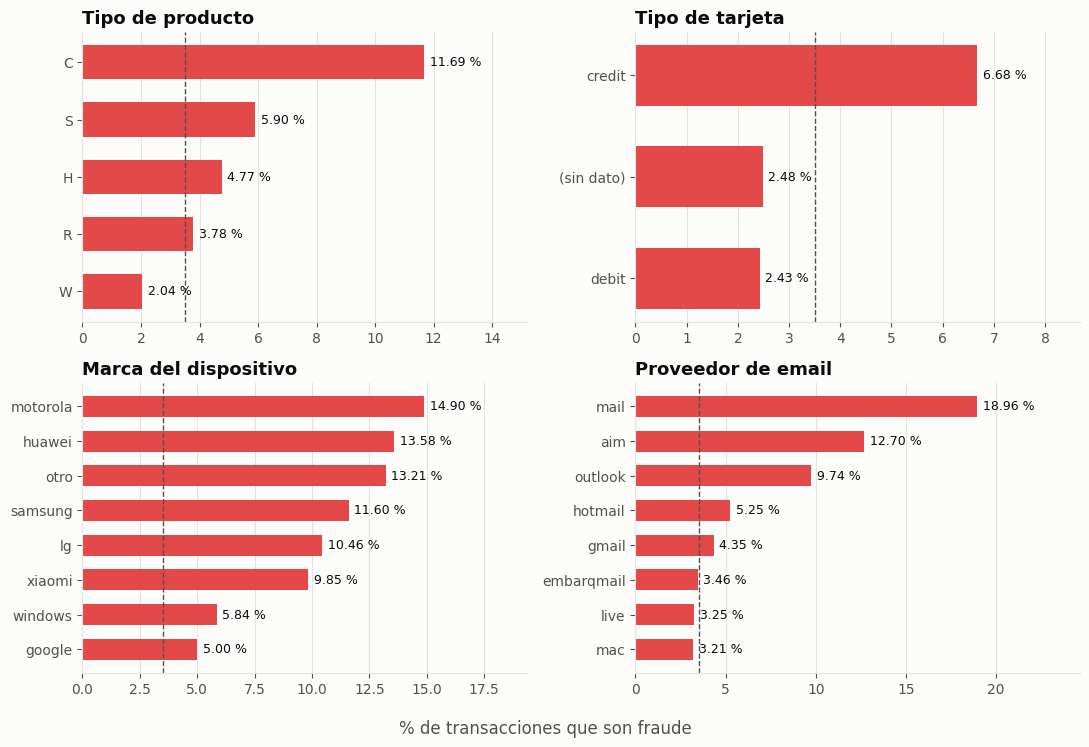

,segmento,valor,transacciones,fraudes,tasa_fraude_pct,monto_total_usd,monto_fraude_usd
3,P_email_proveedor,mail,559,106,18.962,88104.05,32979.81
58,device_marca,motorola,3510,523,14.900,137443.16,25998.68
59,device_marca,huawei,2415,328,13.582,85264.65,14170.04
60,device_marca,otro,9882,1305,13.206,800304.15,106277.14
4,P_email_proveedor,aim,315,40,12.698,40553.28,4031.50
45,ProductCD,C,68519,8008,11.687,2937570.76,391421.40
61,device_marca,samsung,12091,1402,11.595,678375.51,99080.54
76,hora,7,3704,393,10.610,421726.36,39466.93
62,device_marca,lg,2563,268,10.456,112014.35,19152.38
0,DeviceType,mobile,55645,5657,10.166,3867584.53,546427.47


In [20]:
seg = spark.read.format(TABLE_FORMAT).load(ruta(GOLD, "fraude_por_segmento")).toPandas()
paneles = [("ProductCD", "Tipo de producto"), ("card6", "Tipo de tarjeta"),
           ("device_marca", "Marca del dispositivo"), ("P_email_proveedor", "Proveedor de email")]
paneles = [p for p in paneles if p[0] in seg.segmento.unique()]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, (s, titulo) in zip(axes.flat, paneles):
    d = seg[seg.segmento == s].sort_values("tasa_fraude_pct").tail(8)
    barras = ax.barh(d.valor.astype(str), d.tasa_fraude_pct, color=FRAUDE, height=0.6)
    etiquetar_barras(ax, barras, "{:.2f} %", horizontal=True)
    ax.axvline(tasa_global, color=REFERENCIA, linestyle="--", linewidth=1)
    ax.set_title(titulo)
    ax.set_xlim(0, d.tasa_fraude_pct.max() * 1.3)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
for ax in list(axes.flat)[len(paneles):]:
    ax.set_visible(False)
fig.supxlabel("% de transacciones que son fraude", color=TEXTO_2)
fig.tight_layout()
guardar(fig, "01_fraude_por_segmento")
plt.show()

seg.sort_values("tasa_fraude_pct", ascending=False).head(10)

## 7. Fraude por hora del día

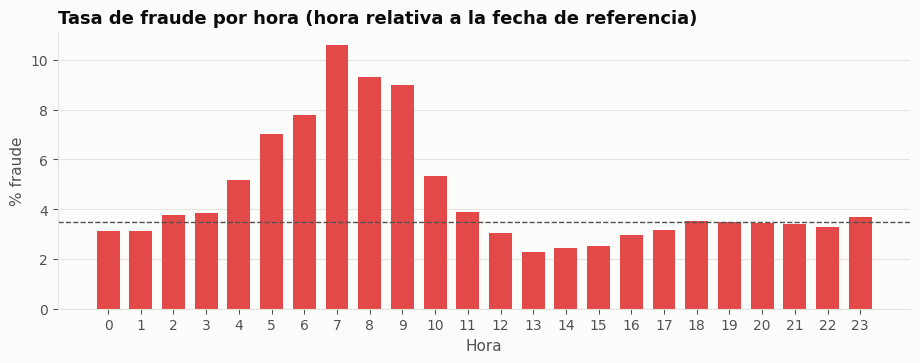

In [21]:
horas = seg[seg.segmento == "hora"].assign(hora=lambda d: d.valor.astype(int)).sort_values("hora")
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(horas.hora, horas.tasa_fraude_pct, color=FRAUDE, width=0.7)
ax.axhline(tasa_global, color=REFERENCIA, linestyle="--", linewidth=1)
ax.set_title("Tasa de fraude por hora (hora relativa a la fecha de referencia)")
ax.set_xlabel("Hora"); ax.set_ylabel("% fraude")
ax.set_xticks(range(0, 24))
guardar(fig, "01_fraude_por_hora")
plt.show()

## 8. Correlaciones

Se calculan sobre una muestra (máx. 100.000 filas) de las variables C (conteos), el monto y la etiqueta.

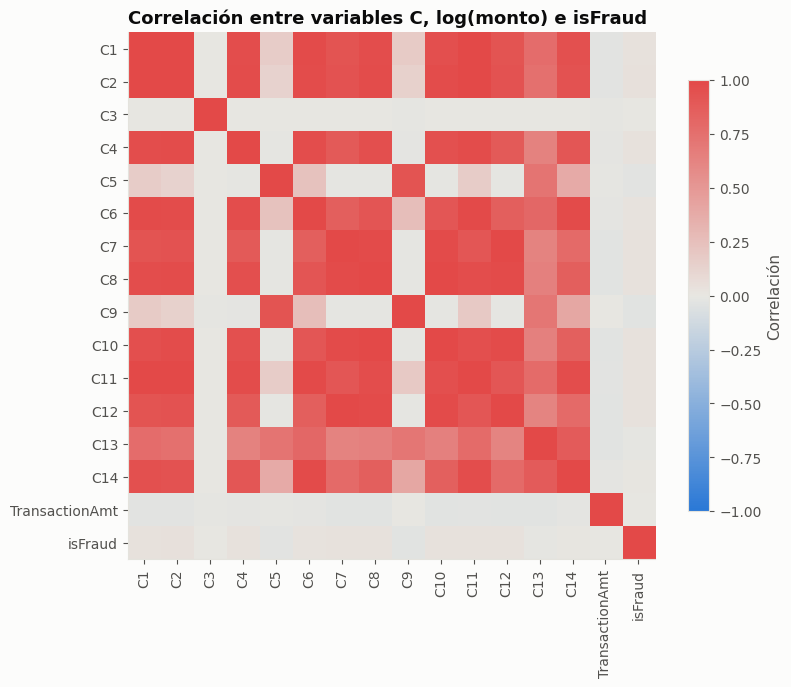

Pares con correlación > 0,9 (candidatos a eliminar por redundancia):
C1   C2     0.995
     C4     0.967
     C6     0.982
     C7     0.923
     C8     0.967
     C10    0.957
     C11    0.997
     C12    0.925
     C14    0.951
C2   C4     0.971
     C6     0.974
     C7     0.935
     C8     0.975
     C10    0.969
     C11    0.994
     C12    0.937
     C14    0.935
C4   C6     0.962
     C8     0.958
     C10    0.950
     C11    0.974
     C14    0.906
C5   C9     0.923
C6   C8     0.919
     C10    0.911
     C11    0.991
     C14    0.984
C7   C8     0.982
     C10    0.984
     C11    0.911
     C12    0.999
C8   C10    0.997
     C11    0.961
     C12    0.982
C10  C11    0.954
     C12    0.983
C11  C12    0.911
     C14    0.962


In [22]:
cols_corr = [c for c in [f"C{i}" for i in range(1, 15)] + ["TransactionAmt", "isFraud"] if c in train.columns]
frac = min(1.0, 100_000 / n_train)
muestra = train.select(cols_corr).sample(fraction=frac, seed=42).toPandas()
muestra["TransactionAmt"] = np.log1p(muestra["TransactionAmt"])
corr = muestra.corr()

from matplotlib.colors import LinearSegmentedColormap
divergente = LinearSegmentedColormap.from_list("div", [LEGITIMA, "#e8e7e2", FRAUDE])
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap=divergente, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90); ax.set_yticks(range(len(corr)), corr.columns)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación")
ax.set_title("Correlación entre variables C, log(monto) e isFraud")
guardar(fig, "01_correlaciones")
plt.show()

altas = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
print("Pares con correlación > 0,9 (candidatos a eliminar por redundancia):")
print(altas[altas.abs() > 0.9].round(3).to_string() or "  ninguno")

## 9. Hallazgos (generados con las cifras de arriba)

In [23]:
top_seg = seg.sort_values("tasa_fraude_pct", ascending=False).iloc[0]
min_prod = seg[seg.segmento == "ProductCD"].sort_values("tasa_fraude_pct").iloc[0] if "ProductCD" in seg.segmento.values else None
mediana, maximo = montos.TransactionAmt.median(), montos.TransactionAmt.max()
hallazgos = [
    f"El {tasa_global:.2f} % de las transacciones del train son fraude: el dataset está desbalanceado y se evaluará con Recall, Precision, F1 y AUC, nunca con accuracy.",
    f"Silver eliminó {len(eliminadas)} columnas con más de 90 % de nulos; de las que quedan, {(nulos > 50).sum()} siguen con más de 50 % de nulos.",
    f"El monto tiene cola larga: mediana {mediana:,.2f} USD y máximo {maximo:,.2f} USD ({maximo / mediana:,.0f} veces la mediana).",
    f"El segmento más riesgoso es {top_seg.segmento} = {top_seg.valor}, con {top_seg.tasa_fraude_pct:.2f} % de fraude frente al {tasa_global:.2f} % global.",
]
if min_prod is not None:
    hallazgos.append(f"El producto menos riesgoso es {min_prod.valor} ({min_prod.tasa_fraude_pct:.2f} %).")
for h in hallazgos:
    print("•", h)
(META / "eda_hallazgos.json").write_text(json.dumps(hallazgos, indent=2, ensure_ascii=False), encoding="utf-8")

• El 3.50 % de las transacciones del train son fraude: el dataset está desbalanceado y se evaluará con Recall, Precision, F1 y AUC, nunca con accuracy.
• Silver eliminó 12 columnas con más de 90 % de nulos; de las que quedan, 204 siguen con más de 50 % de nulos.
• El monto tiene cola larga: mediana 68.77 USD y máximo 31,937.39 USD (464 veces la mediana).
• El segmento más riesgoso es P_email_proveedor = mail, con 18.96 % de fraude frente al 3.50 % global.
• El producto menos riesgoso es W (2.04 %).


521

### Interpretación del equipo

**El desbalance define cómo evaluamos.** Solo el 3,50 % de las 590.540 transacciones del train son fraude (20.663). Un modelo que nunca detecte fraude tendría 96,5 % de accuracy y no serviría para nada; por eso evaluamos con Recall, Precision, F1, ROC-AUC y PR-AUC, y en el modelo cada fraude pesa lo que 27,6 transacciones legítimas.

**Los nulos son parte del dato, no un error.** Silver eliminó 12 columnas con más de 90 % de nulos (D7, dist2 e id_07 a id_27), pero de las 430 que quedan, 405 tienen algún nulo y 204 tienen más de la mitad vacía. Borrar filas con nulos dejaría casi nada. Además, que falte la información de identidad ya dice algo: solo el 24,4 % de las transacciones la tiene. Por eso en Gold los nulos se marcan con -999 en vez de inventar valores.

**El monto tiene una cola muy larga.** La mediana es 68,77 USD y el máximo 31.937 USD, 464 veces la mediana. Los valores extremos no se eliminan porque pueden ser justamente los fraudes caros; se trabaja el monto en escala logarítmica (`log_monto`).

**Hay segmentos de riesgo claros (P1).** Con un promedio de 3,50 %:
- Por producto, C tiene 11,69 % de fraude y W solo 2,04 %: el tipo de producto cambia el riesgo más de cinco veces.
- Las tarjetas de crédito (6,68 %) casi triplican a las débito (2,43 %).
- Por correo del comprador, mail.com llega a 18,96 %, aim a 12,70 % y outlook a 9,74 %, frente a 4,35 % de gmail.
- Las compras desde dispositivos Motorola (14,90 %) y Huawei (13,58 %) están muy por encima del promedio.

Para el negocio, estos segmentos son candidatos a revisión adicional o a reglas específicas mientras el modelo madura.

**El riesgo cambia con la hora y con el tiempo.** Entre las horas 5 y 9 (relativas a la fecha de referencia de Vesta, no son horas reales del reloj) la tasa de fraude sube hasta 10,61 %, tres veces el promedio. A lo largo de los 182 días, la tasa no es estable: empieza por debajo de 3 % y luego se mueve entre 3 % y 5 %. Por eso validamos con los últimos 30 días y no al azar: el modelo tiene que funcionar con datos del futuro.

**Ninguna variable sola explica el fraude.** Las variables C están muy correlacionadas entre sí (son conteos parecidos, información redundante), pero ninguna tiene una correlación lineal fuerte con `isFraud`. El fraude depende de combinaciones de variables, lo que justifica un modelo de árboles (GBT) por encima de uno lineal.

In [24]:
train.unpersist()
spark.stop()